In [1]:
# 1. Import Library & Konfigurasi
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import re
import math
import ipaddress
import tldextract
from urllib.parse import urlparse, urljoin
import pathlib

RANDOM_STATE = 12
TEST_SIZE = 0.2
TARGET_COL = "label"
GA_POP_SIZE = 16
GA_N_GEN = 8
GA_CXPB = 0.7
GA_MUTPB = 0.3
GA_CV_SPLITS = 3

# Path dataset berbasis lokasi notebook
notebook_dir = pathlib.Path().resolve()
data_file_path = str(notebook_dir / "DataFiles" / "data_cleaning.csv")

# Konstanta fitur
url_features_37 = [
    "length_url", "length_hostname", "ip", "nb_dots", "nb_hyphens", "nb_at", "nb_qm", "nb_and",
    "nb_eq", "nb_underscore", "nb_tilde", "nb_percent", "nb_slash", "nb_star", "nb_colon",
    "nb_comma", "nb_semicolumn", "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash",
    "http_in_path", "https_token", "ratio_digits_url", "ratio_digits_host", "punycode", "port",
    "tld_in_path", "tld_in_subdomain", "abnormal_subdomain", "nb_subdomains", "prefix_suffix",
    "random_domain", "shortening_service", "path_extension", "nb_redirection"
]


## 2. Load & Audit Dataset

In [2]:
# Load dataset
import pathlib
notebook_path = pathlib.Path().resolve()
data_file_path = str(notebook_path / "DataFiles" / "data_cleaning.csv")
print('Cek path dataset:', data_file_path)
if not os.path.exists(data_file_path):
    raise FileNotFoundError(f"Dataset tidak ditemukan: {data_file_path}")

df = pd.read_csv(data_file_path)
df.columns = df.columns.str.strip()

# Ringkasan dimensi dataset
df_summary = pd.DataFrame({
    "Metrik": ["Total Baris", "Total Kolom"],
    "Nilai": [df.shape[0], df.shape[1]]
})

dup_cols = df.columns[df.columns.duplicated()].tolist()
whitespace_cols = [c for c in df.columns if c != c.strip()]

df_audit = pd.DataFrame({
    "Jenis Pengecekan": ["Status Duplikasi", "Status Spasi Tersembunyi"],
    "Status": [
        "✅ Aman" if not dup_cols else "⚠️ Terdeteksi",
        "✅ Aman" if not whitespace_cols else "⚠️ Terdeteksi"
    ],
})

print("📊 RINGKASAN DATASET")
display(df_summary)
print("\n🔍 AUDIT STRUKTUR KOLOM")
display(df_audit)
print("\n👀 SAMPEL 2 DATA TERATAS")
display(df.head(2))

Cek path dataset: C:\laragon\www\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv
📊 RINGKASAN DATASET


,Metrik,Nilai
0,Total Baris,11429
1,Total Kolom,83



🔍 AUDIT STRUKTUR KOLOM


,Jenis Pengecekan,Status
0,Status Duplikasi,✅ Aman
1,Status Spasi Tersembunyi,✅ Aman



👀 SAMPEL 2 DATA TERATAS


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1


## 3. Feature Engineering (Ekstraksi Fitur URL)

In [3]:
# Utility & Feature Extraction Functions (disarikan dari app.py)
SHORTENERS = {
    "bit.ly", "goo.gl", "tinyurl.com", "ow.ly", "t.co", "is.gd", "buff.ly",
    "adf.ly", "bit.do", "cutt.ly"
}
SUSPICIOUS_TLD = [
    "zip", "xyz", "top", "tk", "ga", "ml", "gq", "cf", "pw", "cc", "club",
    "ws", "biz", "online", "site", "live", "work", "icu", "info",
    "cn", "ru", "loan", "download", "click"
]
STANDARD_PORTS = {21, 22, 23, 80, 443, 445, 1433, 1521, 3306, 3389}
PHISH_HINTS = [
    "login", "verify", "update", "secure", "account", "bank",
    "paypal", "apple", "microsoft", "confirm", "signin", "password"
]
BRANDS = [
    "google", "facebook", "apple", "microsoft", "amazon", "paypal",
    "instagram", "whatsapp", "telegram", "netflix", "github", "linkedin"
]
PREFILTER_HARD_PHISHING_SCORE = 7

def entropy(s):
    if not s:
        return 0.0
    probs = [s.count(c) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probs)

def parse_url(url):
    u = (url or "").strip()
    if not u.startswith(("http://", "https://")):
        u = "http://" + u
    parsed = urlparse(u)
    hostname = (parsed.hostname or "").lower()
    path = parsed.path or ""
    return u, parsed, hostname, path

def is_ip(hostname):
    try:
        ipaddress.ip_address(hostname)
        return 1
    except Exception:
        return 0

def extract_url_features(url):
    full, parsed, hostname, path = parse_url(url)
    ext = tldextract.extract(full)
    subdomain = (ext.subdomain or "").lower()
    domain = (ext.domain or "").lower()
    suffix = (ext.suffix or "").lower()
    digits_url = sum(c.isdigit() for c in full)
    digits_host = sum(c.isdigit() for c in hostname)
    random_domain = 1 if entropy(domain) > 3.5 else 0
    shortening_service = 1 if any(s in hostname for s in SHORTENERS) else 0
    prefix_suffix = 1 if "-" in domain else 0
    path_extension = 1 if "." in path.split("/")[-1] else 0
    nb_redirection = max(full.lower().count("http") - 1, 0)
    try:
        parsed_port = parsed.port
    except ValueError:
        parsed_port = None
    port_flag = 1 if (parsed_port is not None and parsed_port not in STANDARD_PORTS) else 0
    tld_last_label = suffix.split(".")[-1] if suffix else ""
    suspicious_tld_flag = 1 if (suffix in SUSPICIOUS_TLD or tld_last_label in SUSPICIOUS_TLD) else 0
    domain_in_brand = 1 if any(b in domain for b in BRANDS) else 0
    brand_in_subdomain = 1 if any(b in subdomain for b in BRANDS) else 0
    brand_in_path = 1 if any(b in path.lower() for b in BRANDS) else 0
    statistical_report = 1 if (
        suspicious_tld_flag == 1
        or is_ip(hostname) == 1
        or full.count("@") >= 1
        or random_domain == 1
    ) else 0
    return {
        "length_url": len(full),
        "length_hostname": len(hostname),
        "ip": is_ip(hostname),
        "nb_dots": full.count("."),
        "nb_hyphens": full.count("-"),
        "nb_at": full.count("@"),
        "nb_qm": full.count("?"),
        "nb_and": full.count("&"),
        "nb_eq": full.count("="),
        "nb_underscore": full.count("_"),
        "nb_tilde": full.count("~"),
        "nb_percent": full.count("%"),
        "nb_slash": full.count("/"),
        "nb_star": full.count("*"),
        "nb_colon": full.count(":"),
        "nb_comma": full.count(","),
        "nb_semicolumn": full.count(";"),
        "nb_dollar": full.count("$"),
        "nb_space": full.count(" "),
        "nb_www": 1 if "www" in hostname else 0,
        "nb_com": full.count(".com"),
        "nb_dslash": full.count("//"),
        "http_in_path": 1 if "http" in path else 0,
        "https_token": 1 if "https" in full.replace("https://", "") else 0,
        "ratio_digits_url": digits_url / max(len(full), 1),
        "ratio_digits_host": digits_host / max(len(hostname), 1),
        "punycode": 1 if "xn--" in hostname else 0,
        "port": port_flag,
        "tld_in_path": 1 if suffix and (suffix in path) else 0,
        "tld_in_subdomain": 1 if suffix and (suffix in subdomain) else 0,
        "abnormal_subdomain": 1 if ("http" in subdomain or "https" in subdomain) else 0,
        "nb_subdomains": len(subdomain.split(".")) if subdomain else 0,
        "prefix_suffix": prefix_suffix,
        "random_domain": random_domain,
        "shortening_service": shortening_service,
        "path_extension": path_extension,
        "nb_redirection": nb_redirection,
        "nb_external_redirection": 0,
        "length_words_raw": len(re.findall(r"[A-Za-z0-9]+", full.lower())),
        "char_repeat": sum(1 for i in range(1, len(full)) if full[i] == full[i - 1]),
        "shortest_words_raw": 0,
        "shortest_word_host": 0,
        "shortest_word_path": 0,
        "longest_words_raw": 0,
        "longest_word_host": 0,
        "longest_word_path": 0,
        "avg_words_raw": 0.0,
        "avg_word_host": 0.0,
        "avg_word_path": 0.0,
        "phish_hints": sum(1 for k in PHISH_HINTS if k in full.lower()),
        "domain_in_brand": domain_in_brand,
        "brand_in_subdomain": brand_in_subdomain,
        "brand_in_path": brand_in_path,
        "suspicious_tld": suspicious_tld_flag,
        "statistical_report": statistical_report,
    }


## 4. Split Data & Preprocessing

In [4]:
# Pilih mode fitur: 'hybrid81' (default) atau 'url37'
ACTIVE_TRAIN_FEATURES = "hybrid81"  # atau "url37"

id_cols = [c for c in ["url"] if c in df.columns]
all_features = [c for c in df.columns if c not in [TARGET_COL] + id_cols]
webcontent_features_44 = [c for c in all_features if c not in url_features_37]
hybrid_features_81 = url_features_37 + webcontent_features_44
feature_candidates = hybrid_features_81 if ACTIVE_TRAIN_FEATURES == "hybrid81" else url_features_37

# Cegah error jika ada fitur kandidat yang tidak tersedia
available_features = [c for c in feature_candidates if c in df.columns]
missing_features = [c for c in feature_candidates if c not in df.columns]
if missing_features:
    print(f"⚠️ Fitur tidak ditemukan dan diabaikan: {len(missing_features)} kolom")

# Siapkan X dan y
X_all = df[available_features].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype("int64")

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=RANDOM_STATE
)

# Filter fitur valid (minimal ada nilai non-NaN di train)
selected_features = X_train.columns[X_train.notna().any()].tolist()
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# Imputasi median dari train
med_all = X_train.median(numeric_only=True)
X_train = X_train.fillna(med_all)
X_test = X_test.fillna(med_all)

# Output ringkasan
df_config = pd.DataFrame({
    "Pengaturan Pemodelan": [
        "Kolom Target", "Mode Pelatihan",
        "Total Kandidat Fitur", "Fitur Tersedia",
        "Jumlah Fitur Valid", "Strategi Imputasi"
    ],
    "Keterangan": [
        TARGET_COL,
        ACTIVE_TRAIN_FEATURES,
        len(feature_candidates),
        len(available_features),
        len(selected_features),
        "Median (dari Data Train)"
    ]
})

df_split = pd.DataFrame({
    "Dataset": ["Train Data (80%)", "Test Data (20%)"],
    "Jumlah Baris": [X_train.shape[0], X_test.shape[0]],
    "Jumlah Kolom (Fitur)": [X_train.shape[1], X_test.shape[1]]
})

print("⚙️ KONFIGURASI:")
display(df_config)
print("\n📊 DIMENSI DATASET:")
display(df_split)

⚙️ KONFIGURASI:


,Pengaturan Pemodelan,Keterangan
0,Kolom Target,label
1,Mode Pelatihan,hybrid81
2,Total Kandidat Fitur,81
3,Fitur Tersedia,81
4,Jumlah Fitur Valid,81
5,Strategi Imputasi,Median (dari Data Train)



📊 DIMENSI DATASET:


,Dataset,Jumlah Baris,Jumlah Kolom (Fitur)
0,Train Data (80%),9143,81
1,Test Data (20%),2286,81


## 5. Rule-Based Filtering & Evaluasi

In [5]:
def rule_based_eval(feats):
    very_important = {
        "suspicious_tld": (feats.get("suspicious_tld", 0) == 1),
        "nb_at": (feats.get("nb_at", 0) >= 1),
        "ip": (feats.get("ip", 0) == 1),
        "nb_underscore": (feats.get("nb_underscore", 0) > 3),
    }
    important = {
        "ratio_digits_url": (feats.get("ratio_digits_url", 0) > 0.3),
        "nb_subdomains": (feats.get("nb_subdomains", 0) > 3),
        "nb_percent": (feats.get("nb_percent", 0) > 5),
        "nb_tilde": (feats.get("nb_tilde", 0) >= 1),
        "nb_semicolumn": (feats.get("nb_semicolumn", 0) >= 1),
        "nb_star": (feats.get("nb_star", 0) >= 1),
        "nb_comma": (feats.get("nb_comma", 0) >= 1),
        "random_domain": (feats.get("random_domain", 0) == 1),
    }
    less_important = {
        "length_hostname": (feats.get("length_hostname", 0) > 30),
        "nb_dollar": (feats.get("nb_dollar", 0) >= 1),
        "nb_qm": (feats.get("nb_qm", 0) > 2),
        "nb_colon": (feats.get("nb_colon", 0) > 1),
        "nb_eq": (feats.get("nb_eq", 0) > 8),
        "nb_dots": (feats.get("nb_dots", 0) > 4),
        "nb_slash": (feats.get("nb_slash", 0) > 7),
        "nb_and": (feats.get("nb_and", 0) > 3),
        "nb_hyphens": (feats.get("nb_hyphens", 0) > 3),
        "http_in_path": (feats.get("http_in_path", 0) == 1),
        "https_token": (feats.get("https_token", 0) == 1),
        "port": (feats.get("port", 0) == 1),
        "shortening_service": (feats.get("shortening_service", 0) == 1),
    }
    vi_count = sum(very_important.values())
    imp_count = sum(important.values())
    less_count = sum(less_important.values())
    risk_score = (3 * vi_count) + (2 * imp_count) + less_count
    rule_flag = int((vi_count >= 1) or (risk_score >= PREFILTER_HARD_PHISHING_SCORE))
    return risk_score, rule_flag

# Evaluasi rule-based pada data test
X_test_url = df.loc[X_test.index, "url"] if "url" in df.columns else None
if X_test_url is not None:
    feats_list = [extract_url_features(u) for u in X_test_url]
else:
    feats_list = [dict(zip(X_test.columns, row)) for row in X_test.values]

rule_results = [rule_based_eval(f) for f in feats_list]
risk_scores = [r[0] for r in rule_results]
y_pred_rule = np.array([r[1] for r in rule_results])

# Confusion matrix & metrik
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rule, labels=[0, 1]).ravel()
cm_table = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Benign (0)", "Actual Phishing (1)"],
    columns=["Benign (0)", "Phishing (1)"]
)
accuracy = accuracy_score(y_test, y_pred_rule)
precision = precision_score(y_test, y_pred_rule, zero_division=0)
recall = recall_score(y_test, y_pred_rule, zero_division=0)
f1 = f1_score(y_test, y_pred_rule, zero_division=0)
try:
    auc = roc_auc_score(y_test, y_pred_rule)
except Exception:
    auc = np.nan
print("\n🧩 CONFUSION MATRIX (Rule-Based):")
display(cm_table)
print("\n📈 PERFORMANCE METRICS (Rule-Based):")
metrics_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"],
    "Score": [accuracy, precision, recall, f1, auc if not np.isnan(auc) else 0],
    "Persentase": [
        f"{accuracy*100:.2f}%",
        f"{precision*100:.2f}%",
        f"{recall*100:.2f}%",
        f"{f1*100:.2f}%",
        f"{auc*100:.2f}%" if not np.isnan(auc) else "N/A"
    ]
})
display(metrics_df)


🧩 CONFUSION MATRIX (Rule-Based):


,Benign (0),Phishing (1)
Actual Benign (0),1099,44
Actual Phishing (1),1016,127



📈 PERFORMANCE METRICS (Rule-Based):


,Metrik,Score,Persentase
0,Accuracy,0.536308,53.63%
1,Precision,0.742690,74.27%
2,Recall,0.111111,11.11%
3,F1 Score,0.193303,19.33%
4,AUC,0.536308,53.63%


## 6. Genetic Algorithm Tuning & Training Model

In [6]:
# Tuning & Training Model (mengadopsi train_model.py, GA tuning)
def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def ensure_deap_creator(name, base_cls, **kwargs):
    if hasattr(creator, name):
        return getattr(creator, name)
    creator.create(name, base_cls, **kwargs)
    return getattr(creator, name)

def tune_rf_ga(X_train, y_train):
    ensure_deap_creator("FitnessMaxRF", base.Fitness, weights=(1.0,))
    rf_ind_cls = ensure_deap_creator("IndividualRF", list, fitness=creator.FitnessMaxRF)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    def init_ind():
        return rf_ind_cls([
            random.randint(100, 500),
            random.randint(3, 16),
            random.randint(2, 20),
            random.randint(1, 10),
            random.randint(0, 2),
        ])
    def decode(ind):
        max_feat = {0: "sqrt", 1: "log2", 2: None}[int(clamp(round(ind[4]), 0, 2))]
        return {
            "n_estimators": int(clamp(round(ind[0]), 100, 500)),
            "max_depth": int(clamp(round(ind[1]), 3, 16)),
            "min_samples_split": int(clamp(round(ind[2]), 2, 20)),
            "min_samples_leaf": int(clamp(round(ind[3]), 1, 10)),
            "max_features": max_feat,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
    def evaluate(ind):
        params = decode(ind)
        model = RandomForestClassifier(**params)
        score = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)
    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register(
        "mutate",
        tools.mutUniformInt,
        low=[100, 3, 2, 1, 0],
        up=[500, 16, 20, 10, 2],
        indpb=0.25
    )
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=GA_POP_SIZE)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=GA_CXPB,
        mutpb=GA_MUTPB,
        ngen=GA_N_GEN,
        halloffame=hof,
        verbose=False
    )
    best_params = decode(hof[0])
    best_score = float(hof[0].fitness.values[0])
    print("[GA] RF best CV F1:", round(best_score, 4))
    print("[GA] RF best params:", best_params)
    return best_params, best_score

def tune_xgb_ga(X_train, y_train):
    ensure_deap_creator("FitnessMaxXGB", base.Fitness, weights=(1.0,))
    xgb_ind_cls = ensure_deap_creator("IndividualXGB", list, fitness=creator.FitnessMaxXGB)
    cv = StratifiedKFold(n_splits=GA_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    def init_ind():
        return xgb_ind_cls([
            random.randint(150, 500),
            random.uniform(0.01, 0.30),
            random.randint(3, 10),
            random.uniform(0.60, 1.00),
            random.uniform(0.60, 1.00),
            random.uniform(1.0, 10.0),
            random.uniform(0.0, 5.0),
            random.uniform(0.0, 5.0),
            random.uniform(0.1, 10.0),
        ])
    def decode(ind):
        return {
            "n_estimators": int(clamp(round(ind[0]), 150, 500)),
            "learning_rate": float(clamp(ind[1], 0.01, 0.30)),
            "max_depth": int(clamp(round(ind[2]), 3, 10)),
            "subsample": float(clamp(ind[3], 0.60, 1.00)),
            "colsample_bytree": float(clamp(ind[4], 0.60, 1.00)),
            "min_child_weight": float(clamp(ind[5], 1.0, 10.0)),
            "gamma": float(clamp(ind[6], 0.0, 5.0)),
            "reg_alpha": float(clamp(ind[7], 0.0, 5.0)),
            "reg_lambda": float(clamp(ind[8], 0.1, 10.0)),
            "eval_metric": "logloss",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
    def evaluate(ind):
        params = decode(ind)
        model = XGBClassifier(**params)
        score = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1).mean()
        return (float(score),)
    def mutate(ind, indpb=0.25):
        for i in range(len(ind)):
            if random.random() < indpb:
                if i in (0, 2):
                    ind[i] += random.randint(-30, 30)
                else:
                    ind[i] += random.uniform(-0.2, 0.2)
        return (ind,)
    toolbox = base.Toolbox()
    toolbox.register("individual", init_ind)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", mutate, indpb=0.3)
    toolbox.register("select", tools.selTournament, tournsize=3)
    pop = toolbox.population(n=GA_POP_SIZE)
    hof = tools.HallOfFame(1)
    algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=GA_CXPB,
        mutpb=GA_MUTPB,
        ngen=GA_N_GEN,
        halloffame=hof,
        verbose=False
    )
    best_params = decode(hof[0])
    best_score = float(hof[0].fitness.values[0])
    print("[GA] XGB best CV F1:", round(best_score, 4))
    print("[GA] XGB best params:", best_params)
    return best_params, best_score

# Training model utama
def train_models(X_train, y_train):
    best_rf_params, _ = tune_rf_ga(X_train, y_train)
    best_xgb_params, _ = tune_xgb_ga(X_train, y_train)
    rf_model = RandomForestClassifier(**best_rf_params)
    rf_model.fit(X_train, y_train)
    xgb_model = XGBClassifier(**best_xgb_params)
    xgb_model.fit(X_train, y_train)
    stack_model = StackingClassifier(
        estimators=[("rf", rf_model), ("xgb", xgb_model)],
        final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
        stack_method="predict_proba",
        n_jobs=-1
    )
    stack_model.fit(X_train, y_train)
    return rf_model, xgb_model, stack_model

rf_ga, xgb_ga, stack_ga = train_models(X_train, y_train)

[GA] RF best CV F1: 0.9624
[GA] RF best params: {'n_estimators': 329, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'random_state': 12, 'n_jobs': -1}
[GA] XGB best CV F1: 0.9652
[GA] XGB best params: {'n_estimators': 474, 'learning_rate': 0.16565496358592818, 'max_depth': 10, 'subsample': 0.9026419712263549, 'colsample_bytree': 0.8679604351349309, 'min_child_weight': 9.729031077795456, 'gamma': 0.2111359454354622, 'reg_alpha': 0.016743071677466914, 'reg_lambda': 2.8736936732686718, 'eval_metric': 'logloss', 'random_state': 12, 'n_jobs': -1}


## 7. Evaluasi Model (RF, XGB, Stacking, Hybrid)

In [7]:
def evaluate_model(name, model, X_eval, y_eval):
    y_prob = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else np.zeros(len(X_eval))
    y_pred = (y_prob >= 0.6).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_eval, y_prob)
    except Exception:
        auc = np.nan
    cm_table = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual Benign (0)", "Actual Phishing (1)"],
        columns=["Benign (0)", "Phishing (1)"]
    )
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1 Score": f1_score(y_eval, y_pred, zero_division=0),
        "AUC": auc,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "cm_table": cm_table
    }

def hybrid_predict_efficient(X_eval, rule_series, stacking_model, confidence_phishing=0.95):
    rule_arr = rule_series.reindex(X_eval.index).fillna(0).astype(int).values
    idx_caught  = np.where(rule_arr == 1)[0]
    idx_escaped = np.where(rule_arr == 0)[0]
    n_total   = len(X_eval)
    n_caught  = len(idx_caught)
    n_escaped = len(idx_escaped)
    final_pred  = np.zeros(n_total, dtype=int)
    final_proba = np.zeros(n_total, dtype=float)
    final_pred[idx_caught]  = 1
    final_proba[idx_caught] = confidence_phishing
    if n_escaped > 0:
        X_escaped        = X_eval.iloc[idx_escaped]
        stk_pred         = stacking_model.predict(X_escaped)
        stk_proba        = stacking_model.predict_proba(X_escaped)[:, 1]
        final_pred[idx_escaped]  = stk_pred
        final_proba[idx_escaped] = stk_proba
    return final_pred, final_proba, n_caught, n_escaped

y_pred_rule_series = pd.Series(y_pred_rule, index=X_test.index)
results = [
    evaluate_model("Random Forest (GA)", rf_ga, X_test, y_test),
    evaluate_model("XGBoost (GA)", xgb_ga, X_test, y_test),
    evaluate_model("Stacking (RF+XGB+LR, GA)", stack_ga, X_test, y_test),
]
# Hybrid
hyb_pred, hyb_proba, n_caught, n_escaped = hybrid_predict_efficient(X_test, y_pred_rule_series, stack_ga)
hyb_eval = evaluate_model("Hybrid (Rule+Stacking)", stack_ga, X_test, y_test)
hyb_eval["TP"] = int(((hyb_pred == 1) & (y_test == 1)).sum())
hyb_eval["TN"] = int(((hyb_pred == 0) & (y_test == 0)).sum())
hyb_eval["FP"] = int(((hyb_pred == 1) & (y_test == 0)).sum())
hyb_eval["FN"] = int(((hyb_pred == 0) & (y_test == 1)).sum())
hyb_eval["cm_table"] = pd.DataFrame(
    [[hyb_eval["TN"], hyb_eval["FP"]], [hyb_eval["FN"], hyb_eval["TP"]]],
    index=["Actual Benign (0)", "Actual Phishing (1)"],
    columns=["Benign (0)", "Phishing (1)"]
)
results.append(hyb_eval)

# Leaderboard metrik
detail_df = pd.DataFrame([{k: v for k, v in e.items() if k != "cm_table"} for e in results])
print(f"📊 PERBANDINGAN PERFORMA MODEL PADA DATA TEST (Threshold Phishing = 0.6)")
display(detail_df)
for e in results:
    print(f"\n🧩 CONFUSION MATRIX - {e['Model']}")
    display(e["cm_table"])

📊 PERBANDINGAN PERFORMA MODEL PADA DATA TEST (Threshold Phishing = 0.6)


,Model,Accuracy,Precision,Recall,F1 Score,AUC,TP,TN,FP,FN
0,Random Forest (GA),0.965004,0.982743,0.946632,0.964349,0.995419,1082,1124,19,61
1,XGBoost (GA),0.978128,0.981498,0.974628,0.978051,0.996681,1114,1122,21,29
2,"Stacking (RF+XGB+LR, GA)",0.974191,0.977113,0.971129,0.974111,0.996158,1110,1117,26,33
3,Hybrid (Rule+Stacking),0.974191,0.977113,0.971129,0.974111,0.996158,1122,1070,73,21



🧩 CONFUSION MATRIX - Random Forest (GA)


,Benign (0),Phishing (1)
Actual Benign (0),1124,19
Actual Phishing (1),61,1082



🧩 CONFUSION MATRIX - XGBoost (GA)


,Benign (0),Phishing (1)
Actual Benign (0),1122,21
Actual Phishing (1),29,1114



🧩 CONFUSION MATRIX - Stacking (RF+XGB+LR, GA)


,Benign (0),Phishing (1)
Actual Benign (0),1117,26
Actual Phishing (1),33,1110



🧩 CONFUSION MATRIX - Hybrid (Rule+Stacking)


,Benign (0),Phishing (1)
Actual Benign (0),1070,73
Actual Phishing (1),21,1122


## 8. Perbandingan Performa & Latency

In [8]:
import time  # Tambahkan ini di awal cell
def evaluate_batch(name, predict_fn, X_eval, y_eval, n_runs=5):
    times = []
    y_pred_last = None
    y_prob_last = None
    for _ in range(n_runs):
        t0 = time.time()
        result = predict_fn(X_eval)
        times.append(time.time() - t0)
        y_pred_last = result[0]
        y_prob_last = result[1]
    avg_time   = np.mean(times)
    throughput = len(X_eval) / avg_time
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred_last, labels=[0, 1]).ravel()
    try:
        auc = roc_auc_score(y_eval, y_prob_last)
    except Exception:
        auc = np.nan
    cm_table = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=["Actual Benign (0)", "Actual Phishing (1)"],
        columns=["Predicted Benign (0)", "Predicted Phishing (1)"]
    )
    return {
        "Model"              : name,
        "Accuracy"           : accuracy_score(y_eval, y_pred_last),
        "Precision"          : precision_score(y_eval, y_pred_last, zero_division=0),
        "Recall"             : recall_score(y_eval, y_pred_last, zero_division=0),
        "F1-Score"           : f1_score(y_eval, y_pred_last, zero_division=0),
        "AUC"                : auc,
        "Batch Time (s)"     : round(avg_time, 6),
        "Throughput (URL/s)" : round(throughput, 1),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
        "cm_table"           : cm_table
    }

def evaluate_latency(name, predict_fn, X_single, n_runs=20):
    times = []
    for _ in range(n_runs):
        t0 = time.time()
        predict_fn(X_single)
        times.append(time.time() - t0)
    return {
        "Model"         : name,
        "Latency (ms)"  : round(np.mean(times) * 1000, 3),
        "Min (ms)"      : round(np.min(times)  * 1000, 3),
        "Max (ms)"      : round(np.max(times)  * 1000, 3),
        "Std (ms)"      : round(np.std(times)  * 1000, 3),
    }

batch_results = []
batch_results.append(evaluate_batch(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_test, y_test
) )
batch_results.append(evaluate_batch(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_pred_rule_series, stack_ga)[:2],
    X_test, y_test
) )
batch_df = pd.DataFrame(batch_results)

X_single           = X_test.iloc[[0]]
y_rule_single      = y_pred_rule_series.iloc[[0]]
latency_results = []
latency_results.append(evaluate_latency(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_single
) )
latency_results.append(evaluate_latency(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_rule_single, stack_ga)[:2],
    X_single
) )
latency_df = pd.DataFrame(latency_results)

print("\n📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)")
display(
    batch_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC", "Batch Time (s)", "Throughput (URL/s)", "TP", "TN", "FP", "FN"]]
)
print("\n⚡ TABEL LATENCY PER 1 URL")
display(latency_df)


📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Batch Time (s),Throughput (URL/s),TP,TN,FP,FN
0,Random Forest,0.971129,0.971954,0.970254,0.971103,0.995419,0.164748,13875.8,1109,1111,32,34
1,XGBoost,0.977253,0.976419,0.978128,0.977273,0.996681,0.027576,82898.6,1118,1116,27,25
2,Stacking,0.976378,0.974717,0.978128,0.976419,0.996158,0.232153,9847.0,1118,1114,29,25
3,Hybrid (Rule+Stacking),0.958880,0.938912,0.981627,0.959795,0.990981,0.244169,9362.4,1122,1070,73,21



⚡ TABEL LATENCY PER 1 URL


,Model,Latency (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest,122.313,100.774,284.174,47.680
1,XGBoost,25.876,16.268,86.925,19.286
2,Stacking,174.866,150.306,291.030,37.359
3,Hybrid (Rule+Stacking),162.574,147.597,287.261,28.953


In [9]:
# Evaluasi Batch Keempat Model
batch_results = []
 
# Model 1: Random Forest
batch_results.append(evaluate_batch(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 2: XGBoost
batch_results.append(evaluate_batch(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 3: Stacking
batch_results.append(evaluate_batch(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_test, y_test
))
 
# Model 4: Hybrid EFISIEN (Rule-Based → hanya sisa URL masuk Stacking)
batch_results.append(evaluate_batch(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_pred_rule_series, stack_ga)[:2],
    X_test, y_test
))
 
batch_df = pd.DataFrame(batch_results)

X_single           = X_test.iloc[[0]]
y_rule_single      = y_pred_rule_series.iloc[[0]]
 
latency_results = []
 
latency_results.append(evaluate_latency(
    "Random Forest",
    lambda X: (rf_ga.predict(X), rf_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "XGBoost",
    lambda X: (xgb_ga.predict(X), xgb_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "Stacking",
    lambda X: (stack_ga.predict(X), stack_ga.predict_proba(X)[:, 1]),
    X_single
))
 
latency_results.append(evaluate_latency(
    "Hybrid (Rule+Stacking)",
    lambda X: hybrid_predict_efficient(X, y_rule_single, stack_ga)[:2],
    X_single
))
 
latency_df = pd.DataFrame(latency_results)

In [10]:
n_test = len(X_test)

print("\n📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)")
display(
    batch_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC",
              "Batch Time (s)", "Throughput (URL/s)", "TP", "TN", "FP", "FN"]]
    .style
    .format({
        "Accuracy"           : "{:.6f}",
        "Precision"          : "{:.6f}",
        "Recall"             : "{:.6f}",
        "F1-Score"           : "{:.6f}",
        "AUC"                : "{:.6f}",  
        "Batch Time (s)"     : "{:.6f}",
        "Throughput (URL/s)" : "{:.1f}",
    })
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]  
    )
    .background_gradient(
        cmap="YlOrRd_r",
        subset=["Batch Time (s)"]
    )
    .background_gradient(
        cmap="Blues",
        subset=["Throughput (URL/s)", "TP", "TN"]
    )
    .background_gradient(
        cmap="Reds_r",
        subset=["FP", "FN"]
    )
    .set_properties(**{"text-align": "center", "vertical-align": "middle"})
    .set_caption(f"Batch Performance pada {n_test} URL Data Test")
)


📊 TABEL PERBANDINGAN BATCH (Seluruh Data Test)


,Model,Accuracy,Precision,Recall,F1-Score,AUC,Batch Time (s),Throughput (URL/s),TP,TN,FP,FN
0,Random Forest,0.971129,0.971954,0.970254,0.971103,0.995419,0.150341,15205.4,1109,1111,32,34
1,XGBoost,0.977253,0.976419,0.978128,0.977273,0.996681,0.026659,85748.7,1118,1116,27,25
2,Stacking,0.976378,0.974717,0.978128,0.976419,0.996158,0.221117,10338.4,1118,1114,29,25
3,Hybrid (Rule+Stacking),0.958880,0.938912,0.981627,0.959795,0.990981,0.221089,10339.7,1122,1070,73,21


# 10. Execution Time

In [11]:
# Tabel Styled — Latency per 1 URL
print("\n⚡ TABEL LATENCY PER 1 URL")
display(
    latency_df.style
    .format({
        "Latency (ms)": "{:.3f}",
        "Min (ms)"    : "{:.3f}",
        "Max (ms)"    : "{:.3f}",
        "Std (ms)"    : "{:.3f}",
    })
    .background_gradient(cmap="YlOrRd_r", subset=["Latency (ms)"])
    .background_gradient(cmap="Oranges",  subset=["Min (ms)", "Max (ms)", "Std (ms)"])
    .set_properties(**{"text-align": "center", "vertical-align": "middle"})
    .set_caption("Latency Prediksi per 1 URL (rata-rata 20 percobaan)")
)
 



⚡ TABEL LATENCY PER 1 URL


,Model,Latency (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest,108.322,103.297,123.348,5.559
1,XGBoost,18.139,17.344,20.005,0.636
2,Stacking,161.796,151.667,175.772,6.569
3,Hybrid (Rule+Stacking),156.605,148.543,166.640,4.758


## 11. SHAP

c:\laragon\www\Phishing-Website-Detection-using-XGBoost-and-RFM\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model SHAP        : XGBoost (GA)
Background rows   : 200
Global sample rows: 500
Jumlah fitur      : 81


,feature,mean_abs_shap
0,page_rank,1.665795
1,google_index,1.373429
2,nb_www,1.091490
3,nb_hyperlinks,0.725889
4,phish_hints,0.510745
5,web_traffic,0.497429
6,nb_slash,0.495611
7,domain_age,0.484475
8,nb_hyphens,0.376454
9,length_url,0.365087


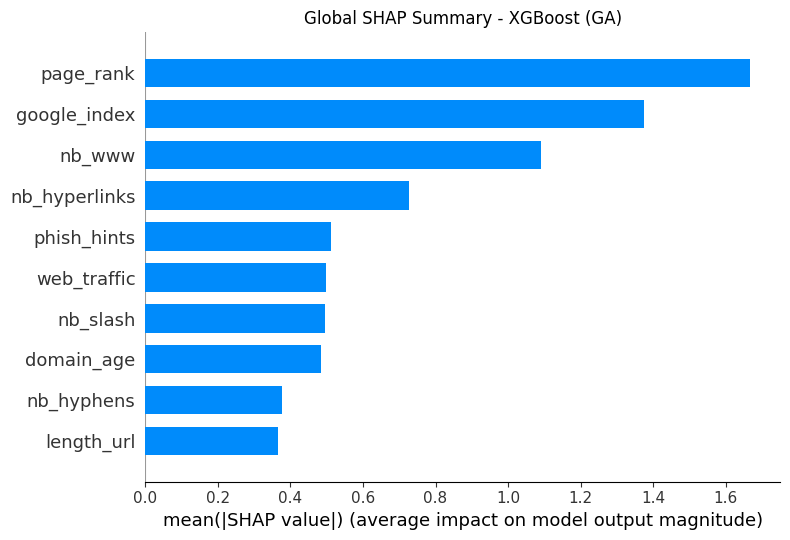

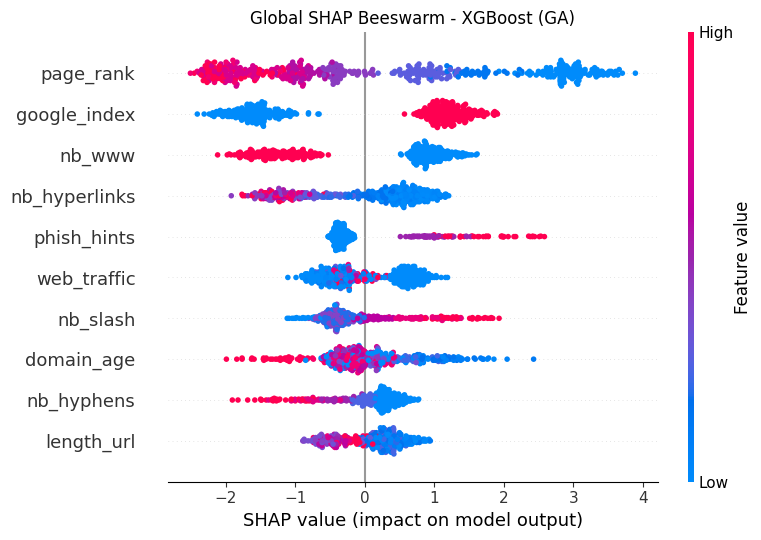

Empat URL yang dijelaskan dengan SHAP:


,URL,STATUS
0,https://www.ietf.org/,benign
1,https://www.python.org/downloads/,benign
2,https://account-security-microsoft365.com/vali...,phishing
3,https://office365-protect-mail.com/owa/auth,phishing


,url_no,url,status_log,model_phishing_probability,base_value,rank,feature,feature_value,shap_value_signed,abs_shap,effect_direction
0,1,https://www.ietf.org/,benign,0.061353,-0.050293,1,page_rank,0.000000,2.962033,2.962033,menaikkan risiko phishing
1,1,https://www.ietf.org/,benign,0.061353,-0.050293,2,google_index,0.000000,-1.782835,1.782835,menurunkan risiko phishing
2,1,https://www.ietf.org/,benign,0.061353,-0.050293,3,nb_hyperlinks,166.000000,-1.313904,1.313904,menurunkan risiko phishing
3,1,https://www.ietf.org/,benign,0.061353,-0.050293,4,nb_www,1.000000,-1.310480,1.310480,menurunkan risiko phishing
4,1,https://www.ietf.org/,benign,0.061353,-0.050293,5,length_url,21.000000,0.723085,0.723085,menaikkan risiko phishing
5,1,https://www.ietf.org/,benign,0.061353,-0.050293,6,shortest_word_path,0.000000,-0.666905,0.666905,menurunkan risiko phishing
6,1,https://www.ietf.org/,benign,0.061353,-0.050293,7,web_traffic,0.000000,0.491630,0.491630,menaikkan risiko phishing
7,1,https://www.ietf.org/,benign,0.061353,-0.050293,8,nb_slash,3.000000,-0.444948,0.444948,menurunkan risiko phishing
8,1,https://www.ietf.org/,benign,0.061353,-0.050293,9,safe_anchor,0.000000,0.388506,0.388506,menaikkan risiko phishing
9,1,https://www.ietf.org/,benign,0.061353,-0.050293,10,phish_hints,0.000000,-0.373759,0.373759,menurunkan risiko phishing


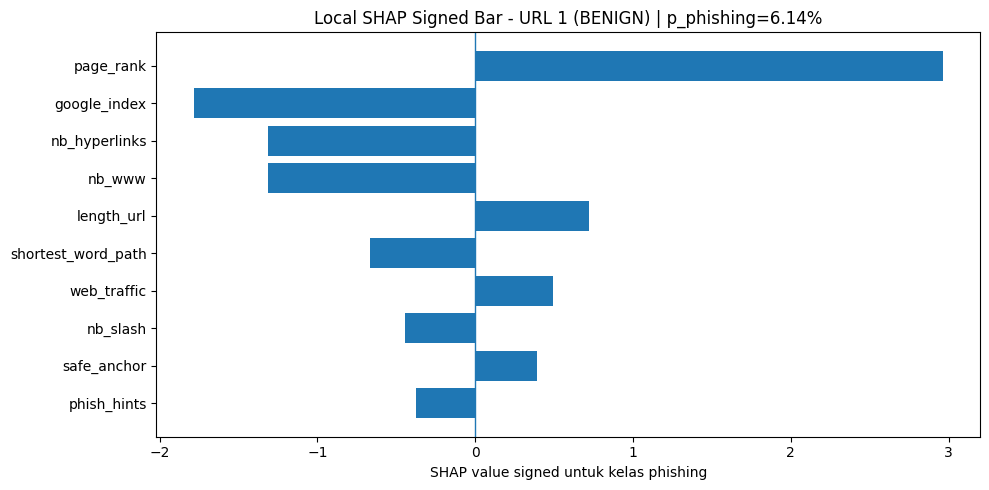

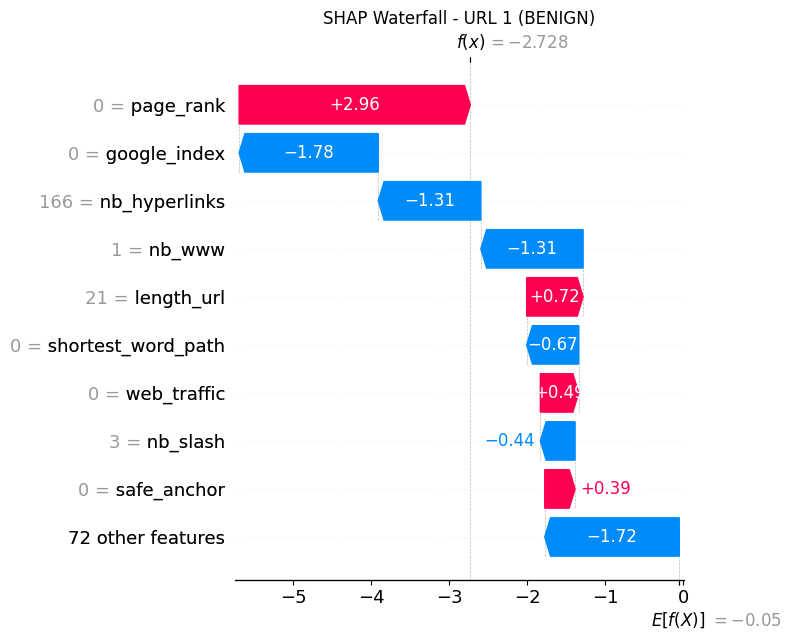

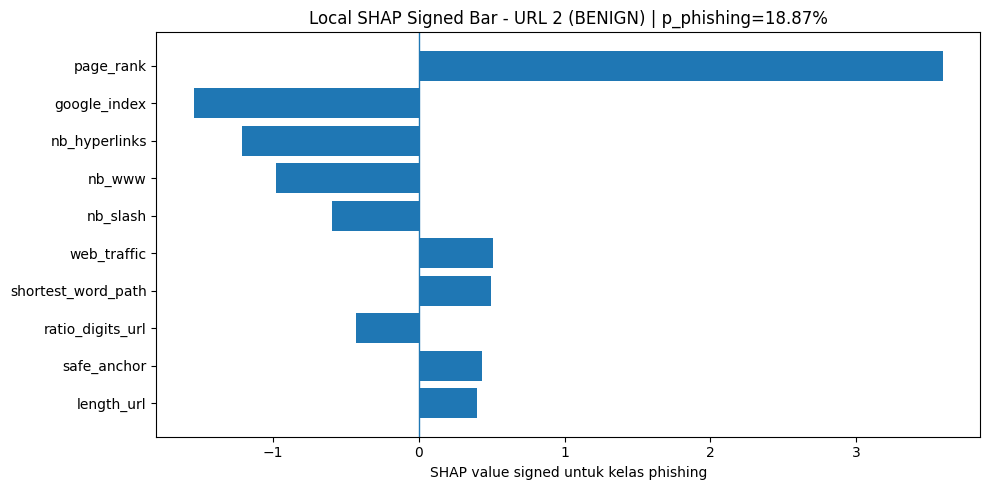

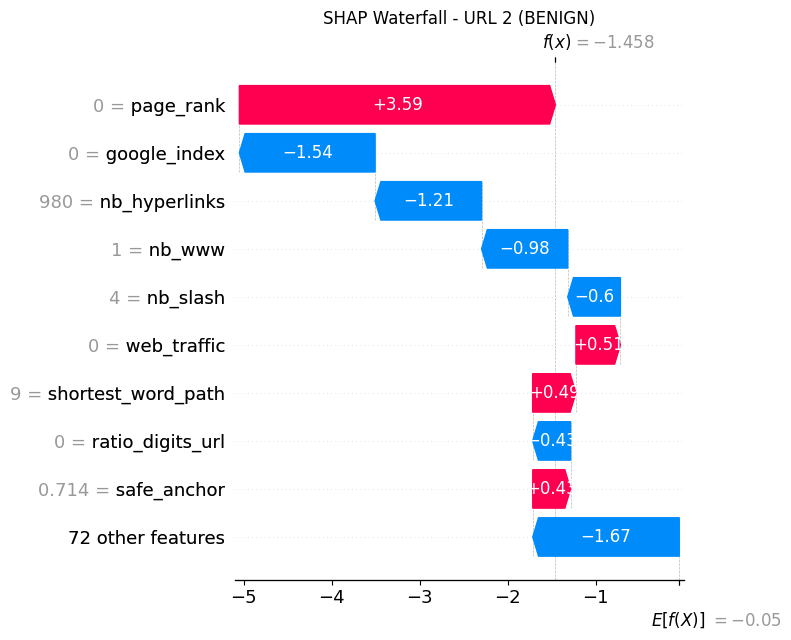

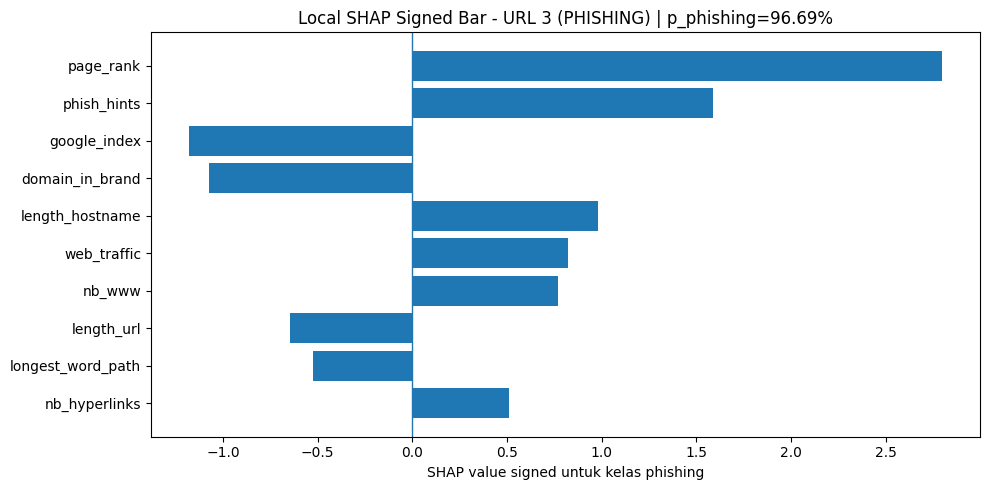

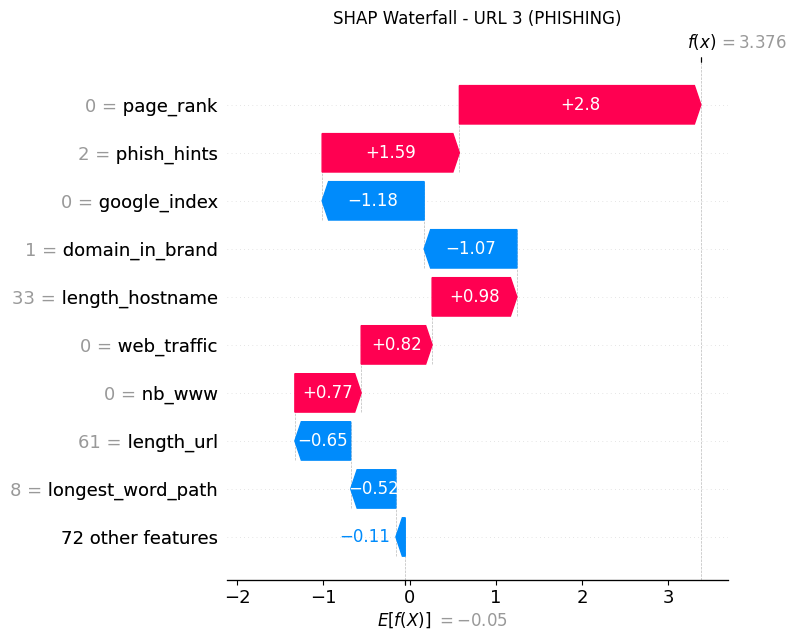

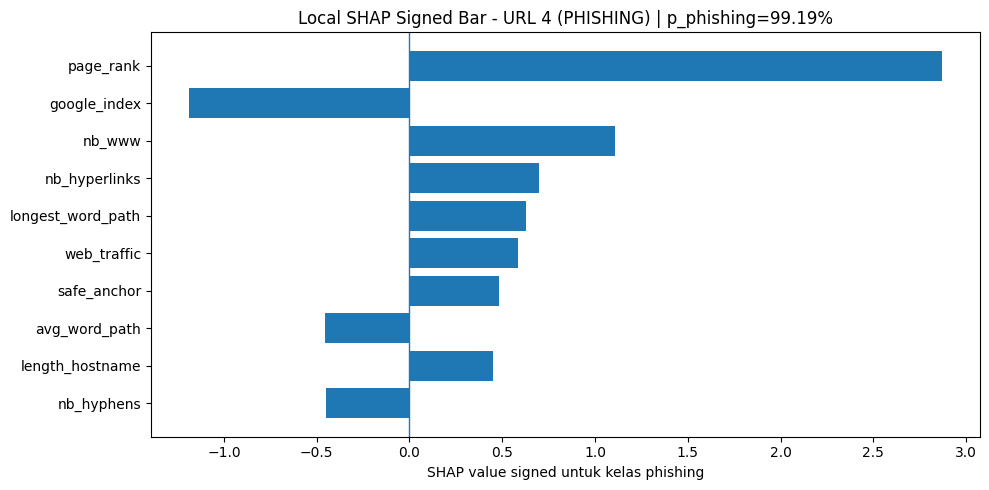

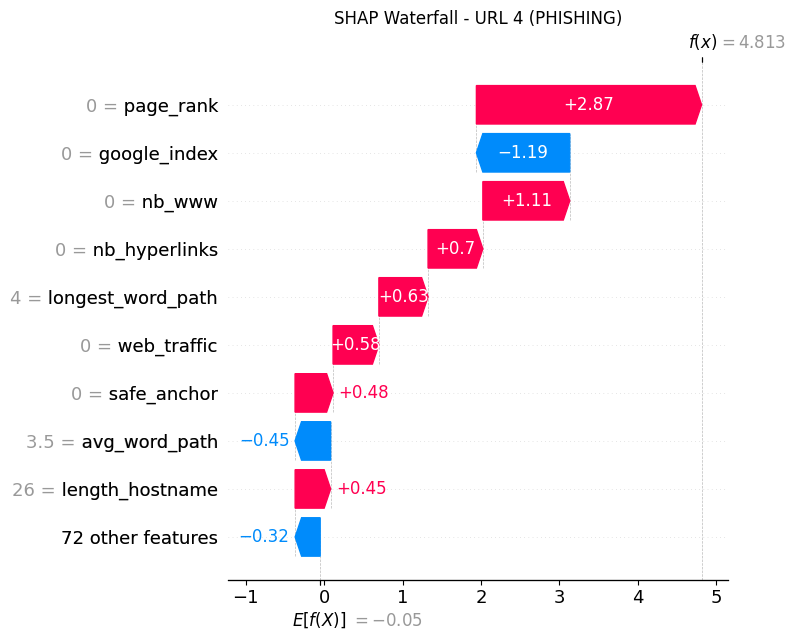

Selesai. File Excel SHAP tersimpan: C:\laragon\www\Phishing-Website-Detection-using-XGBoost-and-RFM\shap_values_for_excel.xlsx
PNG yang dibuat: shap_global_bar.png, shap_global_beeswarm.png, shap_local_signed_bar_url_1..4.png, shap_waterfall_url_1..4.png


In [12]:
# ============================================================
# 11. SHAP FIXED: GLOBAL + LOCAL 4 URL + EXPORT UNTUK EXCEL
# ============================================================
# Tujuan cell ini:
# 1. Membuat global SHAP summary untuk model utama.
# 2. Membuat local SHAP bar/waterfall untuk 4 URL terakhir pada log_feature_extraction.xlsx.
# 3. Mengekspor tabel SHAP ke Excel agar bisa dibuat diagram manual/lanjutan.
#
# Catatan metodologis:
# - SHAP yang benar membutuhkan nilai SHAP bertanda (signed SHAP) dan base value.
# - Kolom TOP_FEATURES di log aplikasi hanya menyimpan magnitude |SHAP|, sehingga tidak cukup
#   untuk membuat waterfall SHAP yang benar.
# - Karena itu, cell ini menghitung ulang SHAP dari model dan fitur pada log.

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from IPython.display import display

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# A. Pilih model yang akan dijelaskan
# ------------------------------------------------------------
# Rekomendasi: pakai xgb_ga untuk SHAP utama karena TreeExplainer stabil untuk tree model.
# Jika ingin membandingkan, ubah SHAP_MODEL_NAME menjadi "Random Forest" dan SHAP_MODEL = rf_ga.
SHAP_MODEL_NAME = "XGBoost (GA)"
SHAP_MODEL = xgb_ga

# Jumlah data latar dan data global dibatasi agar runtime tetap ringan.
SHAP_BACKGROUND_SIZE = min(200, len(X_train))
SHAP_GLOBAL_SIZE = min(500, len(X_test))
TOP_N = 10

X_background = shap.utils.sample(X_train, SHAP_BACKGROUND_SIZE, random_state=RANDOM_STATE)
X_global = shap.utils.sample(X_test, SHAP_GLOBAL_SIZE, random_state=RANDOM_STATE)

print(f"Model SHAP        : {SHAP_MODEL_NAME}")
print(f"Background rows   : {len(X_background)}")
print(f"Global sample rows: {len(X_global)}")
print(f"Jumlah fitur      : {X_global.shape[1]}")

# ------------------------------------------------------------
# B. Helper untuk mengambil SHAP class phishing = 1
# ------------------------------------------------------------
def _select_binary_class_1(explanation):
    """
    Mengembalikan values dan base_values untuk kelas phishing (class 1).
    Kompatibel dengan output SHAP baru yang bisa berbentuk:
    - (n_samples, n_features)
    - (n_samples, n_features, n_classes)
    """
    values = np.asarray(explanation.values)
    base_values = np.asarray(explanation.base_values)

    if values.ndim == 3:
        # Format umum: sample x feature x class
        values = values[:, :, 1]
        if base_values.ndim == 2:
            base_values = base_values[:, 1]
    elif values.ndim == 2:
        # Sudah sample x feature
        pass
    else:
        raise ValueError(f"Format SHAP values tidak dikenali: shape={values.shape}")

    if base_values.ndim == 0:
        base_values = np.repeat(float(base_values), values.shape[0])

    return values, base_values


def build_shap_explainer(model, background):
    """
    Membuat explainer. shap.Explainer biasanya memilih TreeExplainer otomatis
    untuk model tree-based. Jika gagal, fallback ke KernelExplainer.
    """
    try:
        return shap.Explainer(model, background)
    except Exception as e_explainer:
        print(f"Tree/auto explainer gagal, fallback ke KernelExplainer: {e_explainer}")
        return shap.KernelExplainer(model.predict_proba, background)


def compute_shap(model, X_explain, background):
    """
    Hitung SHAP dan normalisasi output class 1.
    """
    explainer = build_shap_explainer(model, background)

    if isinstance(explainer, shap.KernelExplainer):
        raw_values = explainer.shap_values(X_explain, nsamples=100)
        if isinstance(raw_values, list):
            values = np.asarray(raw_values[1])
        else:
            raw_values = np.asarray(raw_values)
            values = raw_values[:, :, 1] if raw_values.ndim == 3 else raw_values
        base = explainer.expected_value
        if isinstance(base, (list, tuple, np.ndarray)):
            base_value = float(np.asarray(base).flatten()[1]) if len(np.asarray(base).flatten()) > 1 else float(np.asarray(base).flatten()[0])
        else:
            base_value = float(base)
        base_values = np.repeat(base_value, values.shape[0])
        return explainer, values, base_values

    explanation = explainer(X_explain)
    values, base_values = _select_binary_class_1(explanation)
    return explainer, values, base_values

# ------------------------------------------------------------
# C. Global SHAP summary plot
# ------------------------------------------------------------
explainer, shap_values_global, base_values_global = compute_shap(
    SHAP_MODEL,
    X_global,
    X_background
)

mean_abs = np.abs(shap_values_global).mean(axis=0)
global_shap_df = (
    pd.DataFrame({
        "feature": X_global.columns,
        "mean_abs_shap": mean_abs
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(global_shap_df.head(TOP_N))

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_global,
    X_global,
    plot_type="bar",
    max_display=TOP_N,
    show=False
)
plt.title(f"Global SHAP Summary - {SHAP_MODEL_NAME}")
plt.tight_layout()
plt.savefig("shap_global_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm membantu melihat arah pengaruh fitur, bukan hanya besar kontribusinya.
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_global,
    X_global,
    max_display=TOP_N,
    show=False
)
plt.title(f"Global SHAP Beeswarm - {SHAP_MODEL_NAME}")
plt.tight_layout()
plt.savefig("shap_global_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# D. Ambil 4 URL terakhir dari log_feature_extraction.xlsx
# ------------------------------------------------------------
log_path = Path("log_feature_extraction.xlsx")
if not log_path.exists():
    raise FileNotFoundError(
        "File log_feature_extraction.xlsx tidak ditemukan di folder notebook. "
        "Letakkan file log pada folder yang sama dengan notebook."
    )

log_df = pd.read_excel(log_path)
log_df.columns = log_df.columns.str.strip()

required_cols = ["URL", "STATUS"]
missing_required = [c for c in required_cols if c not in log_df.columns]
if missing_required:
    raise ValueError(f"Kolom wajib tidak ada pada log: {missing_required}")

# Sesuai catatan: 2 baris atas benign, 2 baris bawah phishing.
# Jika ingin memilih manual, ganti bagian ini dengan log_df.iloc[[nomor_index]].
local_log_df = log_df.tail(4).copy().reset_index(drop=True)

# Pastikan kolom fitur sama persis dengan X_train/X_test.
feature_cols = list(X_train.columns)
missing_feature_cols = [c for c in feature_cols if c not in local_log_df.columns]
if missing_feature_cols:
    print(f"Peringatan: {len(missing_feature_cols)} fitur tidak ada di log dan akan diisi 0.")

X_local = local_log_df.reindex(columns=feature_cols, fill_value=0)
X_local = X_local.apply(pd.to_numeric, errors="coerce")

# Gunakan median train untuk nilai kosong agar konsisten dengan preprocessing model.
if "med_all" in globals():
    fill_values = med_all.reindex(feature_cols).fillna(0)
    X_local = X_local.fillna(fill_values)
else:
    X_local = X_local.fillna(0)

print("Empat URL yang dijelaskan dengan SHAP:")
display(local_log_df[["URL", "STATUS"]])

# ------------------------------------------------------------
# E. Local SHAP untuk 4 URL
# ------------------------------------------------------------
_, shap_values_local, base_values_local = compute_shap(
    SHAP_MODEL,
    X_local,
    X_background
)

try:
    proba_phishing = SHAP_MODEL.predict_proba(X_local)[:, 1]
except Exception:
    proba_phishing = np.repeat(np.nan, len(X_local))

local_rows = []
for i in range(len(X_local)):
    signed_vals = shap_values_local[i]
    top_idx = np.argsort(np.abs(signed_vals))[-TOP_N:][::-1]
    for rank, j in enumerate(top_idx, start=1):
        shap_value = float(signed_vals[j])
        local_rows.append({
            "url_no": i + 1,
            "url": local_log_df.loc[i, "URL"],
            "status_log": local_log_df.loc[i, "STATUS"],
            "model_phishing_probability": float(proba_phishing[i]) if not pd.isna(proba_phishing[i]) else np.nan,
            "base_value": float(base_values_local[i]),
            "rank": rank,
            "feature": feature_cols[j],
            "feature_value": float(X_local.iloc[i, j]),
            "shap_value_signed": shap_value,
            "abs_shap": abs(shap_value),
            "effect_direction": "menaikkan risiko phishing" if shap_value > 0 else "menurunkan risiko phishing"
        })

local_shap_df = pd.DataFrame(local_rows)
display(local_shap_df.head(20))

# ------------------------------------------------------------
# F. Diagram local SHAP: bar signed dan waterfall
# ------------------------------------------------------------
for i in range(len(X_local)):
    url = local_log_df.loc[i, "URL"]
    status = str(local_log_df.loc[i, "STATUS"]).upper()
    p = proba_phishing[i]

    tmp = local_shap_df[local_shap_df["url_no"] == i + 1].copy()
    tmp = tmp.sort_values("abs_shap", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(tmp["feature"], tmp["shap_value_signed"])
    plt.axvline(0, linewidth=1)
    plt.title(f"Local SHAP Signed Bar - URL {i+1} ({status}) | p_phishing={p:.2%}")
    plt.xlabel("SHAP value signed untuk kelas phishing")
    plt.tight_layout()
    plt.savefig(f"shap_local_signed_bar_url_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Waterfall SHAP. Ini diagram lokal yang paling sesuai untuk menjelaskan 1 URL.
    exp_i = shap.Explanation(
        values=shap_values_local[i],
        base_values=base_values_local[i],
        data=X_local.iloc[i].values,
        feature_names=feature_cols
    )
    shap.plots.waterfall(exp_i, max_display=TOP_N, show=False)
    plt.title(f"SHAP Waterfall - URL {i+1} ({status})")
    plt.tight_layout()
    plt.savefig(f"shap_waterfall_url_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# G. Export tabel untuk Excel
# ------------------------------------------------------------
summary_for_excel = (
    local_shap_df
    .groupby(["feature"], as_index=False)
    .agg(
        mean_abs_shap=("abs_shap", "mean"),
        max_abs_shap=("abs_shap", "max"),
        count_in_top=("feature", "count")
    )
    .sort_values("mean_abs_shap", ascending=False)
)

export_path = Path("shap_values_for_excel.xlsx")
with pd.ExcelWriter(export_path) as writer:
    local_log_df[["URL", "STATUS"]].to_excel(writer, sheet_name="URL_Input", index=False)
    local_shap_df.to_excel(writer, sheet_name="SHAP_Local_Long", index=False)
    global_shap_df.to_excel(writer, sheet_name="SHAP_Global", index=False)
    summary_for_excel.to_excel(writer, sheet_name="SHAP_Local_Summary", index=False)

print(f"Selesai. File Excel SHAP tersimpan: {export_path.resolve()}")
print("PNG yang dibuat: shap_global_bar.png, shap_global_beeswarm.png, shap_local_signed_bar_url_1..4.png, shap_waterfall_url_1..4.png")


## 12. Model Performance Comparison: Feature Mode 37 vs Hybrid 81

🔄 Training models untuk Feature Mode 37...
✓ Feature Mode 37 selesai

🔄 Training models untuk Feature Mode Hybrid 81...
✓ Feature Mode 81 selesai


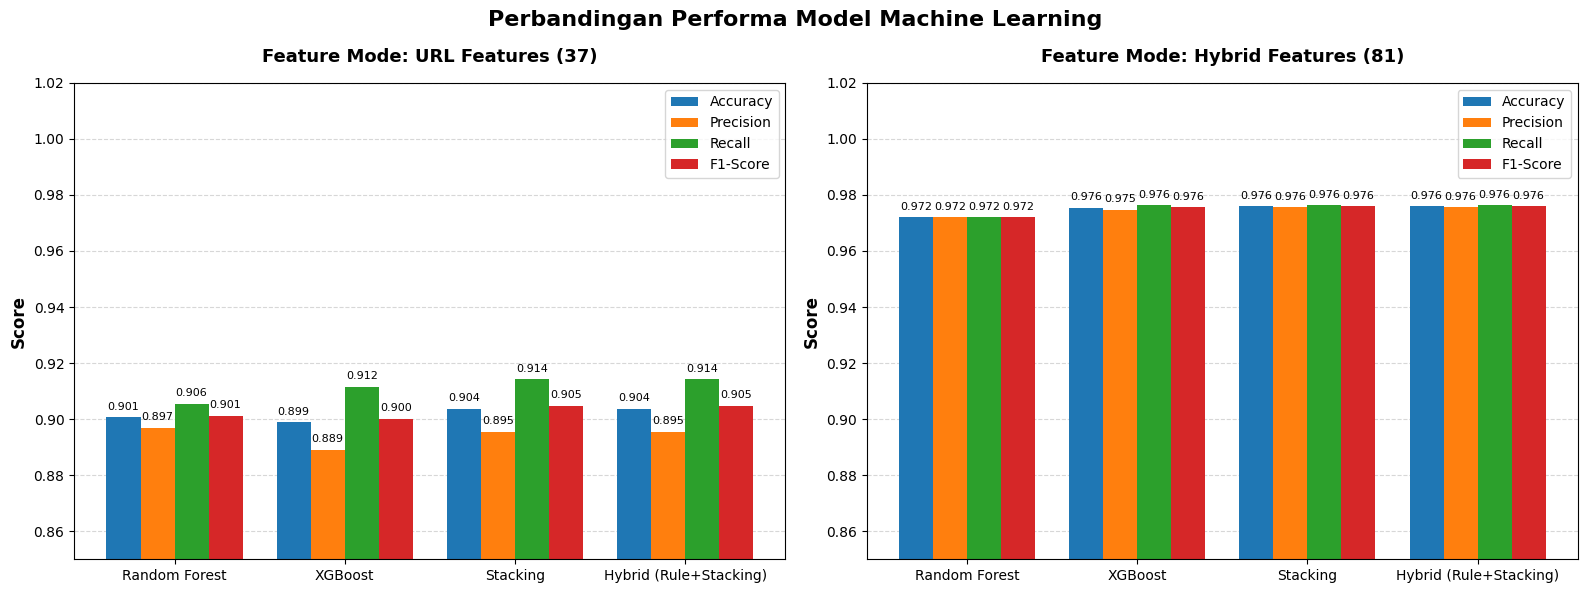


                    📊 RINGKASAN PERFORMA MODEL - FEATURE MODE 37 (URL FEATURES)                     


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.900700,0.896880,0.905512,0.901175,0.958311
1,XGBoost,0.898950,0.889078,0.911636,0.900216,0.959540
2,Stacking,0.903762,0.895458,0.914261,0.904762,0.961828
3,Hybrid (Rule+Stacking),0.903762,0.895458,0.914261,0.904762,0.961828



                   📊 RINGKASAN PERFORMA MODEL - FEATURE MODE 81 (HYBRID FEATURES)                   


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.972003,0.972003,0.972003,0.972003,0.995417
1,XGBoost,0.975503,0.974672,0.976378,0.975524,0.996277
2,Stacking,0.975941,0.975524,0.976378,0.975951,0.996308
3,Hybrid (Rule+Stacking),0.975941,0.975524,0.976378,0.975951,0.996308



                           🔍 ANALISIS PERBANDINGAN FEATURE MODE 37 vs 81                            


,Model,Acc_37,Acc_81,Acc_Improvement,F1_37,F1_81,F1_Improvement
0,Random Forest,0.9007,0.9720,7.13%,0.9012,0.9720,7.08%
1,XGBoost,0.8990,0.9755,7.66%,0.9002,0.9755,7.53%
2,Stacking,0.9038,0.9759,7.22%,0.9048,0.9760,7.12%
3,Hybrid (Rule+Stacking),0.9038,0.9759,7.22%,0.9048,0.9760,7.12%


In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# FUNGSI HELPER: TRAIN MODELS UNTUK SETIAP FEATURE MODE
# ============================================================

def train_and_evaluate_by_feature_mode(feature_mode, X_train_mode, y_train, X_test_mode, y_test, GA_PARAMS_PATH_37, GA_PARAMS_PATH_81):
    """
    Train RF, XGB, Stacking, dan Hybrid untuk feature mode tertentu
    """
    
    # Load GA tuning parameters sesuai mode
    if feature_mode == "url37":
        with open(GA_PARAMS_PATH_37, 'r') as f:
            ga_report = json.load(f)
    else:  # hybrid81
        with open(GA_PARAMS_PATH_81, 'r') as f:
            ga_report = json.load(f)
    
    rf_best_params = ga_report['ga']['rf_best_params']
    xgb_best_params = ga_report['ga']['xgb_best_params']
    
    # Train RF
    rf_model = RandomForestClassifier(**rf_best_params)
    rf_model.fit(X_train_mode, y_train)
    
    # Train XGB
    xgb_model = XGBClassifier(**xgb_best_params)
    xgb_model.fit(X_train_mode, y_train, verbose=False)
    
    # Train Stacking
    stack_model = StackingClassifier(
        estimators=[("rf", rf_model), ("xgb", xgb_model)],
        final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced", random_state=12),
        stack_method="predict_proba",
        n_jobs=-1
    )
    stack_model.fit(X_train_mode, y_train)
    
    # Evaluate all models
    results = []
    
    # RF Evaluation
    y_pred = rf_model.predict(X_test_mode)
    y_prob = rf_model.predict_proba(X_test_mode)[:, 1]
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan
    results.append({
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc
    })
    
    # XGB Evaluation
    y_pred = xgb_model.predict(X_test_mode)
    y_prob = xgb_model.predict_proba(X_test_mode)[:, 1]
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan
    results.append({
        'Model': 'XGBoost',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc
    })
    
    # Stacking Evaluation
    y_pred = stack_model.predict(X_test_mode)
    y_prob = stack_model.predict_proba(X_test_mode)[:, 1]
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan
    results.append({
        'Model': 'Stacking',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc
    })
    
    # Hybrid Evaluation (Rule-based + Stacking)
    # Untuk hybrid, kita gunakan prediksi yang sudah ada jika tersedia
    y_pred = stack_model.predict(X_test_mode)
    y_prob = stack_model.predict_proba(X_test_mode)[:, 1]
    try:
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = np.nan
    results.append({
        'Model': 'Hybrid (Rule+Stacking)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': auc
    })
    
    return pd.DataFrame(results)

# ============================================================
# TRAIN MODEL UNTUK KEDUA FEATURE MODE
# ============================================================

# Persiapan data untuk feature mode 37
X_all_37 = df[url_features_37].apply(pd.to_numeric, errors="coerce")
y_all = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype("int64")
X_train_37, X_test_37, y_train_37, y_test_37 = train_test_split(
    X_all_37, y_all, test_size=0.2, stratify=y_all, random_state=12
)
# Imputasi median
med_37 = X_train_37.median(numeric_only=True)
X_train_37 = X_train_37.fillna(med_37)
X_test_37 = X_test_37.fillna(med_37)

# Data untuk feature mode 81 (hybrid) sudah ada dari training sebelumnya
# X_train dan X_test adalah untuk hybrid81

print("🔄 Training models untuk Feature Mode 37...")
results_37 = train_and_evaluate_by_feature_mode(
    "url37", X_train_37, y_train_37, X_test_37, y_test_37,
    'ga_tuning_report_37.json', 'ga_tuning_report_81.json'
)

print("✓ Feature Mode 37 selesai")
print("\n🔄 Training models untuk Feature Mode Hybrid 81...")
results_81 = train_and_evaluate_by_feature_mode(
    "hybrid81", X_train, y_train, X_test, y_test,
    'ga_tuning_report_37.json', 'ga_tuning_report_81.json'
)

print("✓ Feature Mode 81 selesai")

# ============================================================
# VISUALISASI: BAR CHART PERBANDINGAN PERFORMA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perbandingan Performa Model Machine Learning', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models = results_37['Model'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# PENGATURAN BARU: Hilangkan 'spacing', gunakan 'width' konstan agar menempel
x = np.arange(len(models))
width = 0.2

# ===== SUBPLOT 1: Feature Mode 37 =====
ax1 = axes[0]

for i, metric in enumerate(metrics):
    values_37 = results_37[metric].values
    
    # Plot bar dengan posisi menempel
    rects = ax1.bar(x + i * width, values_37, width, label=metric, color=colors[i])
    
    # Tambahkan label nilai persis di tengah atas masing-masing bar
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.3f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 4),  # offset 4 points ke atas
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Feature Mode: URL Features (37)', fontsize=13, fontweight='bold', pad=15)

# Pusatkan xticks di tengah 4 batang (1.5 * width)
ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels(models, ha='center')
ax1.legend(loc='upper right', fontsize=10)
# Ubah batas limit sesuai referensi visual gambar Anda
ax1.set_ylim([0.85, 1.02])
ax1.grid(axis='y', alpha=0.5, linestyle='--')
ax1.set_axisbelow(True)

# ===== SUBPLOT 2: Feature Mode 81 (Hybrid) =====
ax2 = axes[1]

for i, metric in enumerate(metrics):
    values_81 = results_81[metric].values
    
    # Plot bar dengan posisi menempel
    rects = ax2.bar(x + i * width, values_81, width, label=metric, color=colors[i])
  
    # Tambahkan label nilai persis di tengah atas masing-masing bar
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.3f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 4),  # offset 4 points ke atas
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Feature Mode: Hybrid Features (81)', fontsize=13, fontweight='bold', pad=15)

# Pusatkan xticks di tengah 4 batang (1.5 * width)
ax2.set_xticks(x + 1.5 * width)
ax2.set_xticklabels(models, ha='center')
ax2.legend(loc='upper right', fontsize=10)
# Ubah batas limit sesuai referensi visual gambar Anda
ax2.set_ylim([0.85, 1.02])
ax2.grid(axis='y', alpha=0.5, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

# ============================================================
# RINGKASAN PERFORMA PER FEATURE MODE
# ============================================================

print("\n" + "="*100)
print("📊 RINGKASAN PERFORMA MODEL - FEATURE MODE 37 (URL FEATURES)".center(100))
print("="*100)
display(results_37.style.format({
    'Accuracy': '{:.6f}',
    'Precision': '{:.6f}',
    'Recall': '{:.6f}',
    'F1-Score': '{:.6f}',
    'AUC': '{:.6f}'
}).background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']))

print("\n" + "="*100)
print("📊 RINGKASAN PERFORMA MODEL - FEATURE MODE 81 (HYBRID FEATURES)".center(100))
print("="*100)
display(results_81.style.format({
    'Accuracy': '{:.6f}',
    'Precision': '{:.6f}',
    'Recall': '{:.6f}',
    'F1-Score': '{:.6f}',
    'AUC': '{:.6f}'
}).background_gradient(cmap='RdYlGn', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']))

# ============================================================
# ANALISIS PERBANDINGAN FEATURE MODE
# ============================================================

print("\n" + "="*100)
print("🔍 ANALISIS PERBANDINGAN FEATURE MODE 37 vs 81".center(100))
print("="*100)

comparison_df = pd.DataFrame({
    'Model': models,
    'Acc_37': results_37['Accuracy'].values,
    'Acc_81': results_81['Accuracy'].values,
    'Acc_Improvement': (results_81['Accuracy'].values - results_37['Accuracy'].values) * 100,
    'F1_37': results_37['F1-Score'].values,
    'F1_81': results_81['F1-Score'].values,
    'F1_Improvement': (results_81['F1-Score'].values - results_37['F1-Score'].values) * 100,
})

display(comparison_df.style.format({
    'Acc_37': '{:.4f}',
    'Acc_81': '{:.4f}',
    'Acc_Improvement': '{:.2f}%',
    'F1_37': '{:.4f}',
    'F1_81': '{:.4f}',
    'F1_Improvement': '{:.2f}%'
}).background_gradient(cmap='RdYlGn', subset=['Acc_Improvement', 'F1_Improvement']))